# Quick visualization with `quick_visualize_Q()`

This notebook introduces `nematics3d.quick_visualize_Q()`, a convenience function for getting a first look at a 3D nematic field.

We will use the bundled example file `example/data/Q_example_workflow.npy` and focus on three goals:

- load a sample Q-tensor field
- generate one quick combined visualization
- understand the most important arguments to tweak first


## What `quick_visualize_Q()` is for

The main purpose of `quick_visualize_Q()` is to give you a fast and useful first visualization of a 3D director field with very little code.

It is meant for the stage where you have field data already, and you want to answer questions like these as quickly as possible:

- What does the global director structure look like?
- Where are the main disclination lines?
- If I want to inspect this dataset further, where should I look next?

So this function is best treated as a first-pass overview tool. It helps you get an initial picture before moving on to more detailed and manually controlled workflows.

Internally, it does several things for you in one call:

- builds a `QFieldObject`
- detects defects and classifies disclination lines during initialization
- automatically chooses several visualization scales from the field size
- optionally smooths and plots disclination lines
- adds one director plane through the middle of the sample
- returns both the `QFieldObject` and the `PlotFigure`


## Setup

**For readers who are only interested in the tutorial, this section can be safely skipped.** The next two code cells only do setup work. They import the package and helper modules, locate the repository root, load the bundled example data, and create an output folder for this tutorial. This notebook writes its generated images into its own dedicated subfolder under `tutorials/output/quick_visualize_Q`.

In [1]:
from pathlib import Path
import sys

import numpy as np
from IPython.display import Image, display


def find_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "example" / "data" / "Q_example_workflow.npy").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root from the current working directory."
    )


REPO_ROOT = find_repo_root()

try:
    import nematics3d
except ModuleNotFoundError:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    import nematics3d

DATA_PATH = REPO_ROOT / "example" / "data" / "Q_example_workflow.npy"
OUTPUT_DIR = REPO_ROOT / "tutorials" / "output" / "quick_visualize_Q"
EXAMPLE_IMAGE_PATH = REPO_ROOT / "tutorials" / "output" / "interact_with_figures" / "example.png"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data file: {DATA_PATH}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Example image: {EXAMPLE_IMAGE_PATH}")


Repository root: D:\Document\GitHub\Nematics3D
Data file: D:\Document\GitHub\Nematics3D\example\data\Q_example_workflow.npy
Output folder: D:\Document\GitHub\Nematics3D\tutorials\output\quick_visualize_Q
Example image: D:\Document\GitHub\Nematics3D\tutorials\output\interact_with_figures\example.png


In [2]:
Q_data = np.load(DATA_PATH)
Q_data.shape


(200, 100, 100, 5)

## Minimal example

We start with the default interactive style, because that is the most natural way to use `quick_visualize_Q()` when you are exploring a dataset for the first time.

The input here is intentionally minimal. We pass only one argument:

- `Q=Q_data`: the Q-tensor field loaded from the example file

Everything else is left at its default value, so that you can see the shortest useful call first.

In [3]:
Q_obj, figure = nematics3d.quick_visualize_Q(
    Q=Q_data,
)


[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `Q`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `Q` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='Q'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='Q'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.68 s
[INFO]
        <QFieldObject[name='Q'].act_lines_smooth> 
        There are 8 disclination lines in total, with 7 lines are smoothed.
        The smoothing window length is: 41


A typical result is shown below. The exact window layout, toolbar placement, menu-bar appearance, and font rendering may vary across local environments, but the main plotted content should look similar.

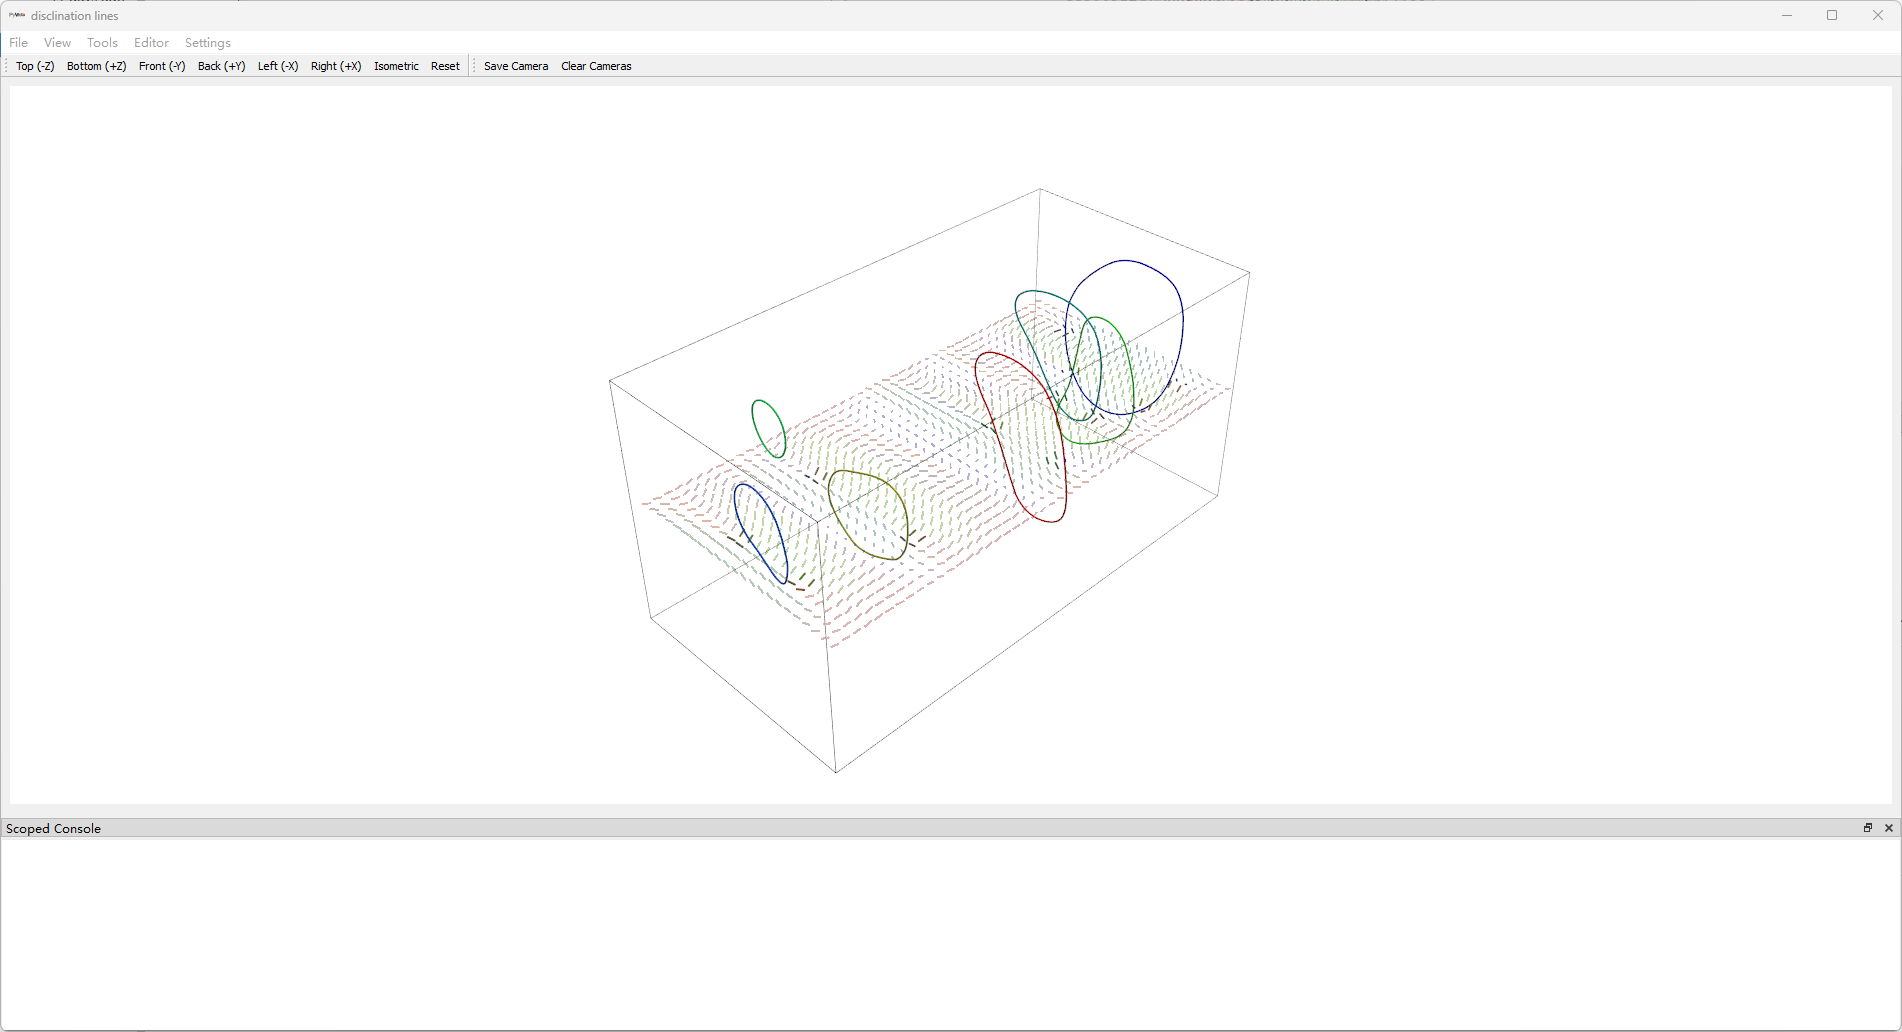

In [7]:
display(Image(filename=EXAMPLE_IMAGE_PATH))

A few things happened in that single call:

- `QFieldObject` was created from the input Q tensor
- defects were detected and grouped into disclination lines
- the lines were smoothed and visualized
- a director plane was inserted through the middle of the volume
- an interactive figure window was created

For a first-pass inspection, this is often enough to answer: *What is the global director structure, and where should I look next?*

At this stage, you can rotate the view, inspect the plotted objects, and decide which regions deserve a closer look.

### What is returned

The function returns two objects:

- `Q_obj`: the underlying `QFieldObject`
- `figure`: the `PlotFigure` used for rendering

That means `quick_visualize_Q()` is not a dead-end helper. You can use it as a fast entry point, then continue with the returned objects for more detailed work.

### Reading the visualization

Once the figure is open, there are a few things to know about how the visual elements are encoded.

**Director color** encodes orientation. Each director glyph is colored by the direction it points. The approximate RGB color for each axis is:

- X axis: `(0.91, 0.23, 0.22)`    red-ish
- Y axis: `(0.05, 0.28, 0.49)`    blue-ish
- Z axis: `(0.30, 0.90, 0.23)`    green-ish

Because the nematic director has no preferred sign (n and âˆ’n are equivalent), opposite directions map to the same color. More details are shown in [Details](#Details).

**Disclination line color** is assigned to make the longest lines visually distinguishable from each other. The coloring scheme is designed so that the largest lines get contrasting colors; shorter lines reuse colors as needed. The color of a line carries no physical meaning â€” it is purely for identification. More details are shown in [Details](#Details).

**Director opacity** distinguishes two regions on the plane. Directors near the intersection of a disclination line with the director plane are rendered fully opaque, which makes them stand out as local landmarks. All other directors on the plane are semi-transparent (opacity 0.2), so they provide context without visually overwhelming the disclination lines. More details are shown in [Details](#Details).

**Director plane position.** By default the plane passes through the center of the simulation box. This parameter is not exposed as an argument to `quick_visualize_Q()`, but the plane position can be adjusted interactively after the figure is created.

## What is the next step?

The most direct next step is often to interact with this figure and inspect the part of the system that looks interesting to you.

For example, after getting this first overview, you might want to:

- rotate the camera and identify the main director structures
- click or inspect plotted objects to understand which line or region you are looking at
- decide which local area deserves a more focused follow-up plot

The workflow of interactively manipulating the figure is covered in [interact_with_figures.ipynb](./interact_with_figures.ipynb).

## Arguments

| Argument | What it controls | Typical form |
| --- | --- | --- |
| `Q` | Input Q-tensor field | Usually a NumPy array with shape `(Nx, Ny, Nz, 5)` or `(Nx, Ny, Nz, 9)` |
| `S` and `n` | Alternative way to build the field | `S`: `(Nx, Ny, Nz)` and `n`: `(Nx, Ny, Nz, 3)`, on the same grid |
| `grid_normal` | Orientation of the director plane | A 3D vector such as `(0, 0, 1)` or `(1, 1, 0)` |
| `director_spacing` | Density of director glyphs on the plane | One of `'dense'`, `'medium'`, or `'sparse'`; default is `'medium'` |
| `is_visualize_lines` | Whether to draw smoothed lines or raw defect points | `True` or `False` |
| `box_periodic_flag` | Periodic boundary condition of the box | Either one boolean like `True`, or three booleans like `(True, False, False)` for x, y, z |
| `name` | Label attached to the created `QFieldObject` | Any string; purely for display purposes, has no effect on the computation |
| `save_path` and `is_off_screen` | Whether to save an image without opening a visible window | For example `save_path=...` together with `is_off_screen=True` |

If you want the full input conventions for `Q`, `S`, and `n`, see [initialize_QFieldObject](./classes/QFieldObject/initialize.ipynb).


### Example: reduce director density

The default `director_spacing='medium'` matches the original behavior of `quick_visualize_Q()`. Try `'dense'` or `'sparse'` for other plotting options.

This parameter only changes the spacing and geometries of plotted directors on the plane. It does not change the disclination-line detection or the overall slice orientation.

[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `workflow_Q_sparse_directors`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `workflow_Q_sparse_directors` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='workflow_Q_sparse_directors'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='workflow_Q_sparse_directors'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.29 s
[INFO]
        <QFieldObject[name='workflow_Q_sparse_directors'].act_lines_smooth> 
        There are 8 disclination lines in total, with 7 lines are smoothed.
        The smoothing 

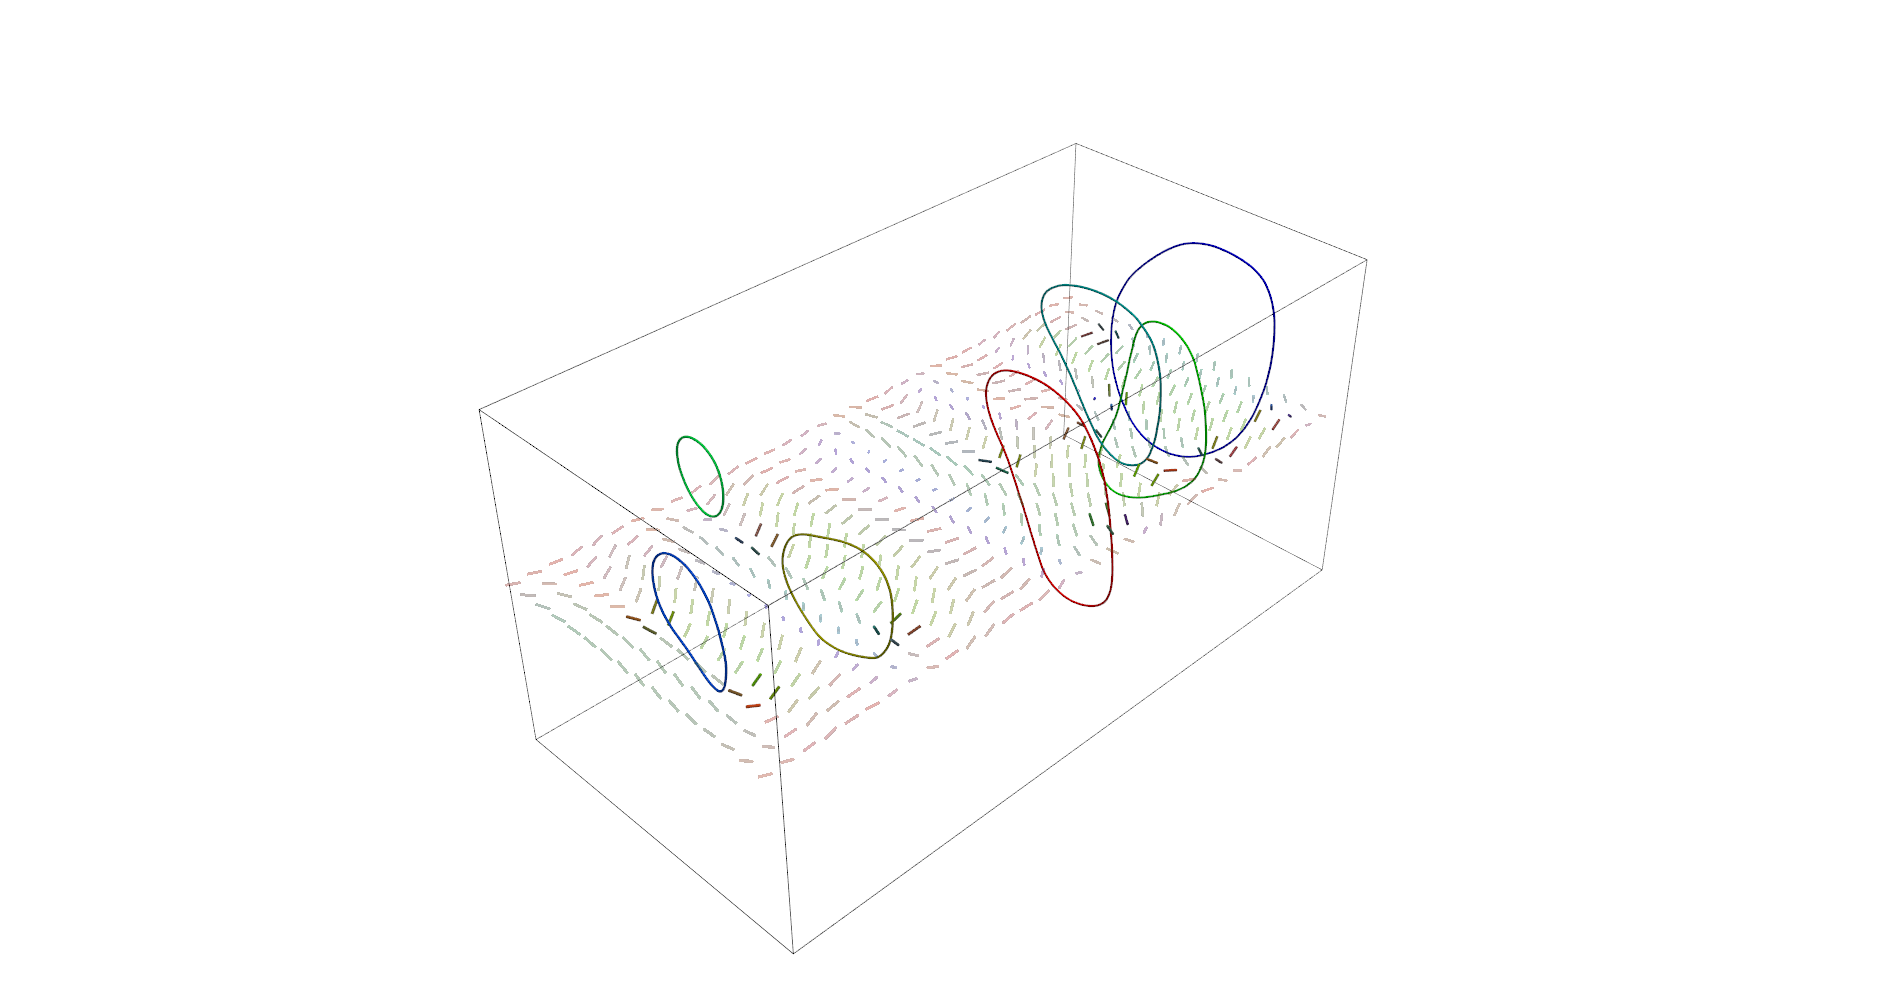

In [4]:
save_path_sparse = OUTPUT_DIR / "quick_sparse_directors.png"

Q_obj_sparse, figure_sparse = nematics3d.quick_visualize_Q(
    Q=Q_data,
    name="workflow_Q_sparse_directors",
    director_spacing="sparse",
    save_path=save_path_sparse,
    is_off_screen=True,
)

display(Image(filename=save_path_sparse))


### Example: change the director plane orientation

By default, the director plane is normal to `(0, 0, 1)`. If you want a different slice through the system, `grid_normal` is the first thing to try.

[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `workflow_Q_tilted_plane`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `workflow_Q_tilted_plane` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='workflow_Q_tilted_plane'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='workflow_Q_tilted_plane'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.24 s
[INFO]
        <QFieldObject[name='workflow_Q_tilted_plane'].act_lines_smooth> 
        There are 8 disclination lines in total, with 7 lines are smoothed.
        The smoothing window length is: 41

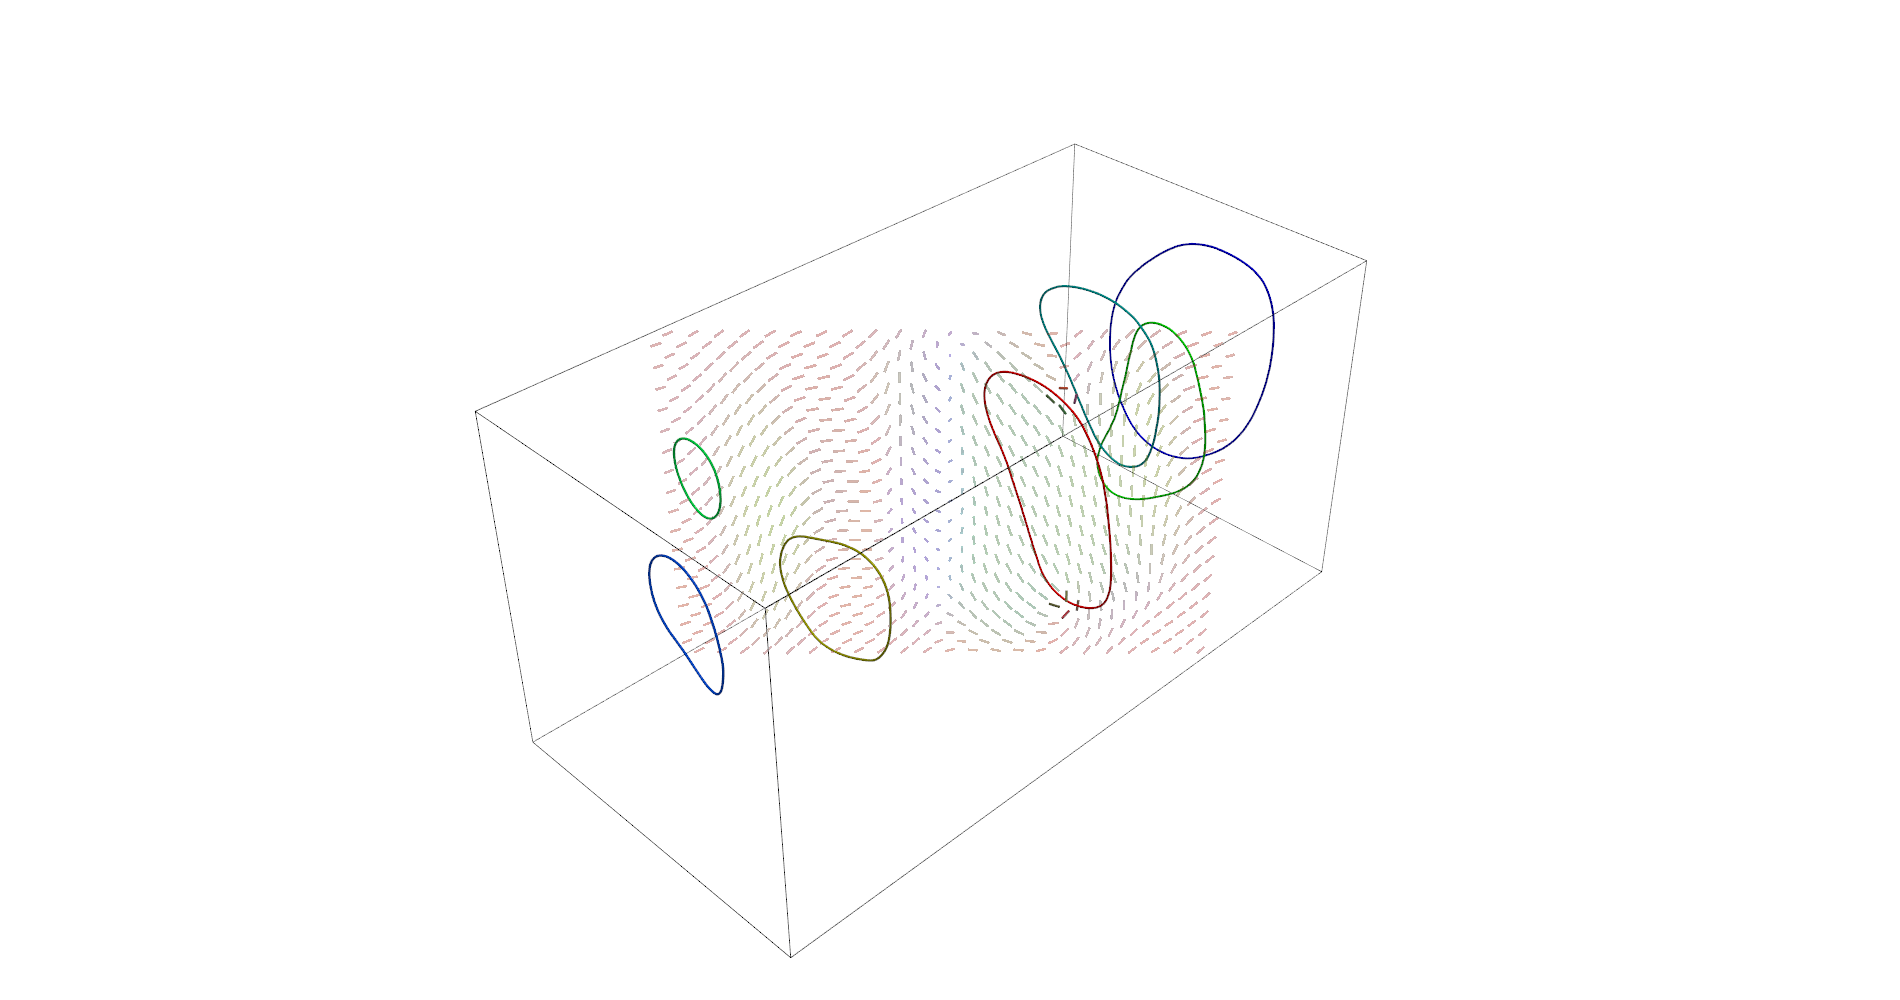

In [5]:
save_path_tilted = OUTPUT_DIR / "tilted_plane.png"

Q_obj_tilted, figure_tilted = nematics3d.quick_visualize_Q(
    Q=Q_data,
    name="workflow_Q_tilted_plane",
    grid_normal=(1, 1, 0),
    save_path=save_path_tilted,
    is_off_screen=True,
)

display(Image(filename=save_path_tilted)) # display the off-screen figure saved by previous command


### Example: show defect points instead of disclination lines

If you set `is_visualize_lines=False`, the function skips line visualization and shows the detected defect points directly. This can be useful when you want to inspect the raw detected structure before the smoothed line representation.

[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `workflow_Q_points`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `workflow_Q_points` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='workflow_Q_points'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='workflow_Q_points'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.49 s


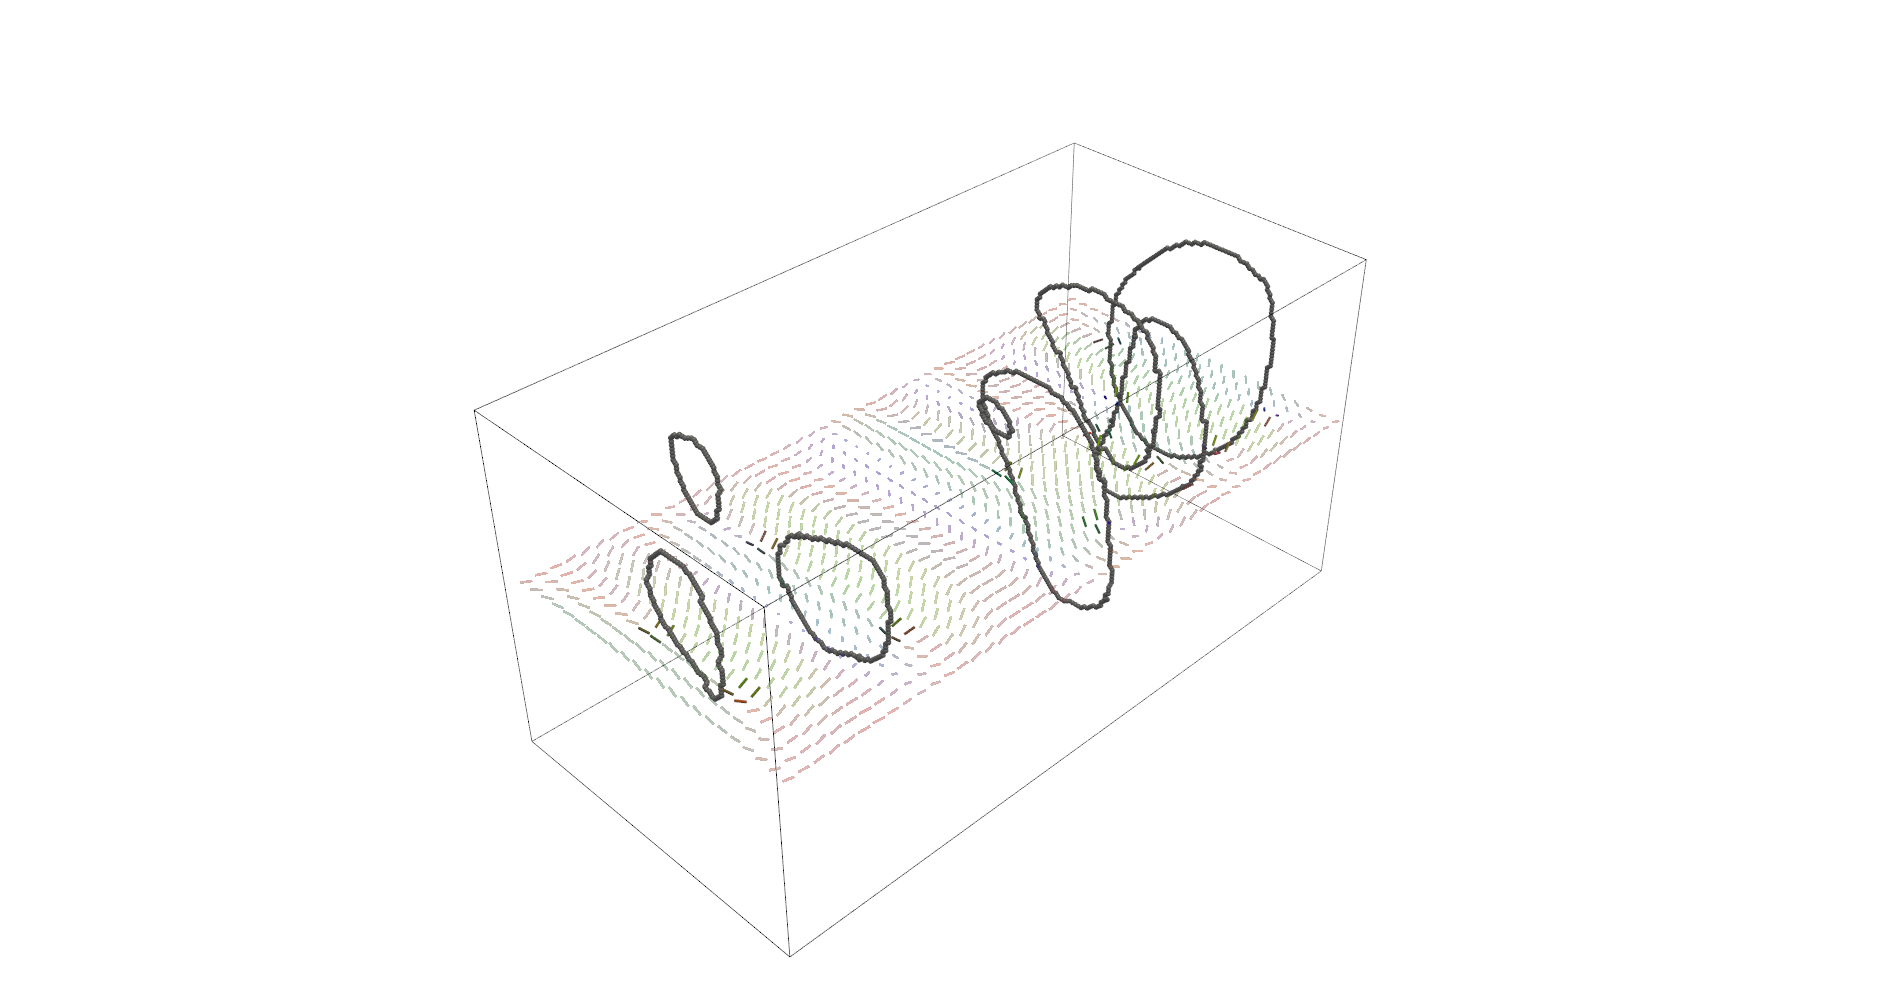

In [6]:
save_path_points = OUTPUT_DIR / "defect_points.png"

Q_obj_points, figure_points = nematics3d.quick_visualize_Q(
    Q=Q_data,
    name="workflow_Q_points",
    is_visualize_lines=False,
    save_path=save_path_points,
    is_off_screen=True,
)

display(Image(filename=save_path_points)) # display the off-screen figure saved by previous command


### About off-screen output

Several later examples in this notebook already use off-screen rendering. The basic idea is simple: provide a `save_path`, set `is_off_screen=True`, and then display the saved image if you want it inline.

## Returned objects

`quick_visualize_Q()` returns two objects. Both can be used directly for further work.

### `QFieldObject`

`Q_obj` is the central data object for the Q-tensor field.
It holds the raw field data, the detected defect points, and the classified
disclination lines built during initialization.
All subsequent analysis — smoothing, further visualization, or quantitative
measurements — is done by calling methods on this object.
For a full overview, see [QFieldObject](./classes/QFieldObject/QFieldObject.ipynb).

### `PlotFigure`

`figure` is the rendering window that `quick_visualize_Q()` created.
You can continue adding objects to it, adjust the camera, change the appearance
of existing glyphs, or export images — all without creating a new window.
For a full overview, see [PlotFigure](./classes/PlotFigure/PlotFigure.ipynb).

## Details

### Director color scheme

Each director glyph is colored using a mapping from orientation to RGB.
Because a nematic director satisfies **n** = **−n**, the mapping must assign the same color
to opposite directions — a requirement that standard vector colormaps cannot meet.
The full set of possible director orientations forms the real projective plane RP²
(the unit sphere with antipodal points identified), so what is needed is a continuous map
from RP² into the RGB cube [0, 1]³.

The mapping used here is a specially designed map from RP² to [0, 1]³,
described in detail in [n_color_immerse()](./field/n_color_immerse.ipynb).
It is constructed to satisfy four goals as well as possible:

1. **Continuity** — nearby orientations receive similar colors.
2. **Injectivity where possible** — different orientations are mapped to different colors
   as much as the topology of RP² allows.
3. **Distance from white** — all colors are kept away from white `(1, 1, 1)`,
   so every director stands out on a white background.
4. **Axis anchoring** — the three coordinate axes are mapped close to primary colors,
   as described in the [*Reading the visualization*](#Reading-the-visualization) section above.

**How to obtain the color sphere**

The color sphere is a unit sphere whose surface is colored by applying this mapping
to each vertex normal. It shows the full colormap at a glance and can be added as an
orientation widget in the corner of the figure window. The easiest way to add it is through the **View** panel in the figure controls.
For the full set of options, see [act_add_axes_widget()](./classes/PlotFigure/act_add_axes_widget.ipynb). As the main view is rotated, the sphere rotates with it, and the color of its visible face
directly encodes the current viewing direction.

### Disclination line color scheme

Each disclination line is assigned a color from
[blue_red_in_white_bg()](./general/blue_red_in_white_bg.ipynb) —
a colormap that transitions from blue through green to red,
with every entry normalized to stand out on a white background.

Lines are sorted by length before colors are assigned.
Colors are picked using [sample_far()](./general/sample_far.ipynb),
an algorithm that makes consecutive picks as far apart as possible along the colormap,
at least for the first several lines. In practice this means:

- the **longest** line is blue
- the **2nd longest** line is red
- the **3rd longest** line is green

The goal is to make the dominant lines visually distinguishable from one another.
Line color carries no physical meaning — it is purely for identification.

### Director opacity

Directors on the plane are split into two groups based on proximity to a defect:

- Directors **near a defect** are fully opaque (opacity 1.0).
- All other directors are semi-transparent (opacity 0.2).

Directors close to a defect core are the most physically interesting part of the plane —
they reveal the local orientation structure around the defect.
Making them fully opaque lets them stand out as local landmarks,
while the background directors at opacity 0.2 still provide spatial context
without cluttering the view.

**How "near a defect" is determined**

Defects are first detected on the plane grid as specific grid positions.
A director is then considered near a defect if it sits within one grid cell
of any detected defect position.

For the full set of options controlling this behavior, see
[act_visualize_n()](./classes/QPlane/act_visualize_n.ipynb).

## Usage tips

### Adjusting parameters interactively

For convenience, many parameters are not exposed as arguments to `quick_visualize_Q()` —
for example, the exact grid spacing, director length, tube radius of disclination lines,
and many others. All of these can be adjusted after the figure is created by
right-double-clicking any plotted glyph to open its interactive control panel.

For instance, if you are unsure whether the disclination lines have been over-smoothed,
right-double-click a disclination line: its control panel will display the raw,
unsmoothed defect coordinates alongside the smoothed representation,
so you can compare them directly.

A full guide to interactive figure controls is in
[interact_with_figures.ipynb](./interact_with_figures.ipynb).

## Possible issues

### Disclination lines and highlighted directors do not line up at the plane

The intersection of a disclination line with the director plane and the
highlighted (fully opaque) directors on the plane are computed independently
from two different grids: the line comes from defect detection on the original full 3D
grid, while the highlighted directors come from defect detection on the 2D
plane grid visualized in this function. If those two grids do not coincide, small positional offsets
between the two are expected. In noisy data, the two can even disagree entirely.

To make them align perfectly, two conditions must hold simultaneously:

1. `grid_normal` must be one of the three coordinate axes — for example
   `(1, 0, 0)`, `(0, 1, 0)`, or `(0, 0, 1)` — so that the plane sits
   exactly on a slice of the 3D integer grid.
2. The director spacing must be set to 1 (one grid cell), so that the plane
   grid samples fall on the same integer positions as the 3D grid.

These two options can be changed via the interactive control panel: right-double-click
   any director to open it.

When both conditions hold, the plane grid coincides exactly with the
corresponding slice of the 3D grid, and the two defect detections are
guaranteed to agree. If you satisfy both conditions and a mismatch still
remains, please report it as a bug.

### Visualization is in grid coordinates only

All plotted positions and lengths are in grid-index units.
No scaling or rotation to physical (real-world) coordinates is applied,
because `quick_visualize_Q()` is designed for a fast check of the raw
grid data — inspecting the director structure and verifying that defect
detection looks reasonable. If you need to work in physical coordinates,
a `grid_transform` can be set on the `QFieldObject` directly;
see [initialize_QFieldObject](./classes/QFieldObject/initialize.ipynb)
for details.

## Useful Links

### Referenced in this tutorial

- [interact_with_figures.ipynb](./interact_with_figures.ipynb) — guide to interacting with the figure window: rotating the camera, clicking glyphs, and opening interactive control panels
- [QFieldObject](./classes/QFieldObject/QFieldObject.ipynb) — overview of the central data object that holds the Q-tensor field, defect points, and disclination lines
- [initialize_QFieldObject](./classes/QFieldObject/initialize.ipynb) — how to construct a `QFieldObject` from Q, S, or n arrays, including input conventions and grid options
- [PlotFigure](./classes/PlotFigure/PlotFigure.ipynb) — overview of the rendering window object returned by `quick_visualize_Q()`
- [act_add_axes_widget()](./classes/PlotFigure/act_add_axes_widget.ipynb) — adds an orientation widget (axes arrows or color sphere) to the corner of the figure window
- [act_visualize_n()](./classes/QPlane/act_visualize_n.ipynb) — visualizes the director field on a `QPlane`, including opacity and near-defect highlighting options
- [n_color_immerse()](./field/n_color_immerse.ipynb) — maps nematic director orientations to RGB colors using a specially designed map from RP² to [0, 1]³
- [blue_red_in_white_bg()](./general/blue_red_in_white_bg.ipynb) — generates the blue-through-green-to-red colormap used for disclination line colors
- [sample_far()](./general/sample_far.ipynb) — picks n maximally-spaced positions along a range, used to assign maximally-distinct colors to disclination lines

### Going deeper

- [act_defect_detect()](./classes/QFieldObject/act_defect_detect.ipynb) — detects defect points from the director field; called automatically during `QFieldObject` initialization
- [act_lines_classify()](./classes/QFieldObject/act_lines_classify.ipynb) — groups detected defect points into individual disclination lines, sorted by length
- [act_lines_smooth()](./classes/QFieldObject/act_lines_smooth.ipynb) — smooths the classified lines; controls the window length and other smoothing parameters that affect how the lines look
- [QPlane](./classes/QPlane/QPlane.ipynb) — the director plane object created inside `quick_visualize_Q()`; holds the sampled director field, the on-plane defect detection result, and the live visuals
- [DisclinationLine](./classes/DisclinationLine/DisclinationLine.ipynb) — the individual line objects stored in `Q_obj.lines`; each one carries the raw defect coordinates, the smoothed representation, and its own visualization methods